# Task 4 — Spam SMS Detection
**CodSoft Machine Learning Internship**

Goal: classify SMS messages as spam or legitimate (ham) using TF-IDF +
classic ML classifiers.

**Before running:** download `spam.csv` from the dataset link in the
CodSoft task PDF and place it in this same folder.

In [1]:
import pandas as pd
import numpy as np
import re
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, ConfusionMatrixDisplay
import joblib

## 1. Load the data
This dataset is famously messy: it needs `latin-1` encoding, and has three
junk "Unnamed" columns from stray commas in the raw text, which we drop.

In [2]:
df = pd.read_csv("spam.csv", encoding="latin-1")
df = df[[c for c in df.columns if not c.startswith("Unnamed")]]
df.columns = ["label", "message"] + list(df.columns[2:])
df = df[["label", "message"]]

print("Shape:", df.shape)
df.head()

Shape: (5572, 2)


,label,message
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


## 2. Class balance

label
ham     4825
spam     747
Name: count, dtype: int64

Spam rate: 13.4%


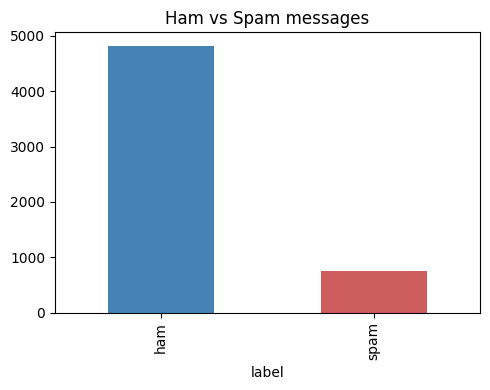

In [3]:
print(df["label"].value_counts())
print(f"\nSpam rate: {(df['label'] == 'spam').mean() * 100:.1f}%")

df["label"].value_counts().plot(kind="bar", color=["steelblue", "indianred"], figsize=(5, 4))
plt.title("Ham vs Spam messages")
plt.tight_layout()
plt.savefig("spam_class_balance.png", dpi=100)
plt.show()

## 3. Encode labels + clean text

In [4]:
df["label_num"] = df["label"].map({"ham": 0, "spam": 1})


def clean_text(text):
    text = str(text).lower()
    text = re.sub(r"[^a-z\s]", " ", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text


df["message_clean"] = df["message"].apply(clean_text)
df[["message", "message_clean", "label_num"]].head(3)

,message,message_clean,label_num
0,"Go until jurong point, crazy.. Available only ...",go until jurong point crazy available only in ...,0
1,Ok lar... Joking wif u oni...,ok lar joking wif u oni,0
2,Free entry in 2 a wkly comp to win FA Cup fina...,free entry in a wkly comp to win fa cup final ...,1


## 4. Train / test split

In [5]:
X_train, X_test, y_train, y_test = train_test_split(
    df["message_clean"], df["label_num"], test_size=0.2, random_state=42, stratify=df["label_num"]
)
print("Train:", X_train.shape[0], "| Test:", X_test.shape[0])

Train: 4457 | Test: 1115


## 5. TF-IDF vectorization

In [6]:
tfidf = TfidfVectorizer(max_features=5000, stop_words="english")
X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)
print("TF-IDF matrix shape:", X_train_tfidf.shape)

TF-IDF matrix shape: (4457, 5000)


## 6. Train models
Naive Bayes is the classic go-to for spam filtering; Logistic Regression
usually edges it out slightly on TF-IDF features, so we compare both.

In [7]:
nb_model = MultinomialNB()
nb_model.fit(X_train_tfidf, y_train)
nb_preds = nb_model.predict(X_test_tfidf)
print("Naive Bayes accuracy:", accuracy_score(y_test, nb_preds))

Naive Bayes accuracy: 0.9704035874439462


In [8]:
lr_model = LogisticRegression(max_iter=1000)
lr_model.fit(X_train_tfidf, y_train)
lr_preds = lr_model.predict(X_test_tfidf)
print("Logistic Regression accuracy:", accuracy_score(y_test, lr_preds))

Logistic Regression accuracy: 0.9695067264573991


## 7. Evaluate the better model in detail

In [9]:
best_preds = lr_preds if accuracy_score(y_test, lr_preds) >= accuracy_score(y_test, nb_preds) else nb_preds
best_model = lr_model if best_preds is lr_preds else nb_model
best_name = "Logistic Regression" if best_preds is lr_preds else "Naive Bayes"
print(f"Best model: {best_name}\n")
print(classification_report(y_test, best_preds, target_names=["ham", "spam"], digits=3))

Best model: Naive Bayes

              precision    recall  f1-score   support

         ham      0.968     0.999     0.983       966
        spam      0.992     0.785     0.876       149

    accuracy                          0.970      1115
   macro avg      0.980     0.892     0.930      1115
weighted avg      0.971     0.970     0.969      1115



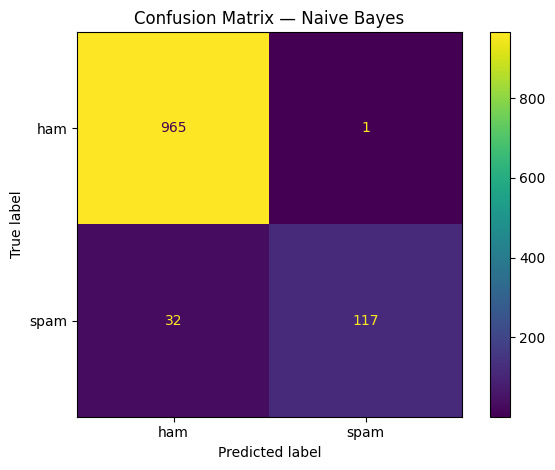

In [10]:
ConfusionMatrixDisplay.from_predictions(y_test, best_preds, display_labels=["ham", "spam"])
plt.title(f"Confusion Matrix — {best_name}")
plt.tight_layout()
plt.savefig("spam_confusion_matrix.png", dpi=100)
plt.show()

## 8. Try it on custom messages
Good cell to show live in your demo video.

In [11]:
sample_messages = [
    "Congratulations! You've won a $1000 Walmart gift card. Click here to claim now!",
    "Hey, are we still meeting for lunch tomorrow at 1pm?",
]
sample_clean = [clean_text(m) for m in sample_messages]
sample_tfidf = tfidf.transform(sample_clean)
predictions = best_model.predict(sample_tfidf)

for msg, pred in zip(sample_messages, predictions):
    print(f"[{'SPAM' if pred == 1 else 'HAM'}]  {msg}")

[SPAM]  Congratulations! You've won a $1000 Walmart gift card. Click here to claim now!
[HAM]  Hey, are we still meeting for lunch tomorrow at 1pm?


## 9. Save the model + vectorizer

In [12]:
joblib.dump(best_model, "spam_detection_model.joblib")
joblib.dump(tfidf, "tfidf_vectorizer.joblib")
print(f"Saved spam_detection_model.joblib ({best_name}) and tfidf_vectorizer.joblib")

Saved spam_detection_model.joblib (Naive Bayes) and tfidf_vectorizer.joblib


## Conclusion
TF-IDF + a simple classifier gets very strong accuracy on this dataset
(typically 96-98%) because spam messages have quite distinctive vocabulary
("free", "win", "claim", "urgent", phone numbers). Worth noting in your
writeup: precision on the spam class matters more than raw accuracy here,
since misclassifying a real message as spam is more annoying than missing
an occasional spam message.